# 차선 검출 및 비교 분석 - KITTI Sequence 09

본 프로젝트에서는 Projection Matrix를 활용한 3D-2D 투영 과정을 분석하고, 차량 궤적 시각화 및 Bayesian 기반 차선 검출을 수행하였다.  
또한 딥러닝 모델(UFLD)을 적용하여 기존 방식과의 차선 검출 성능을 비교하였다.

---

#### 사용 데이터
- KITTI Odometry Dataset (Sequence 09)

#### 사용 기술 및 라이브러리
- NumPy: 수치 연산 및 데이터 처리
- OpenCV: 이미지 입출력 및 전처리, 차선 시각화
- Matplotlib: 결과 시각화
- PyTorch: UFLD 딥러닝 모델 추론
- SciPy: softmax 기반 확률 계산 (후처리 과정)

In [ ]:
# import
import numpy as np
import cv2
import matplotlib.pyplot as plt

# 1. 투영 행렬(Projection Matrix)의 이해

Projection Matrix는 카메라의 내부 파라미터(K)와 외부 파라미터(R, t)를 결합하여,  
월드 좌표계의 3D 점을 카메라 좌표계를 거쳐 2D 이미지 평면으로 투영하는 변환 행렬이다.

전체 구조는 다음과 같다.

$$
P = K [R \mid t]
$$

---

### 1.1 Intrinsic Parameter (K)

$$
K =
\begin{bmatrix}
f_x & 0 & c_x \\
0 & f_y & c_y \\
0 & 0 & 1
\end{bmatrix}
$$

Intrinsic parameter는 카메라 내부 특성을 나타내며, 카메라 좌표계의 점을 이미지 좌표계로 변환하는 역할을 한다.

#### (1) \( f_x, f_y \) : 초점 거리
- 실제 카메라의 초점거리를 픽셀 단위로 표현한 값이다.
- 값이 클수록 이미지에서 물체가 더 크게 보인다.
- 이미지에서 확대 및 축소 정도를 결정한다.
- \( X_c / Z_c \), \( Y_c / Z_c \)에 곱해져 투영 스케일을 조정한다.

#### (2) \( c_x, c_y \) : 주점 (Principal Point)
- 이미지 중심 좌표를 의미한다.
- 카메라의 optical center를 나타낸다.
- 투영된 좌표를 이미지 중심 기준으로 이동시키는 역할을 한다.

Intrinsic parameter는 이미지에서의 위치와 크기를 결정하는 요소이다.

---

### 1.2 Extrinsic Parameter (\( R, t \))

$$
[R \mid t]
$$

Extrinsic parameter는 월드 좌표계의 3D 점을 카메라 좌표계로 변환하는 역할을 한다.

#### (1) \( R \) : 회전 행렬
- 카메라의 방향을 나타낸다.
- 카메라가 어느 방향을 바라보는지를 결정한다.

#### (2) \( t \) : 이동 벡터
- 카메라의 위치를 나타낸다.
- 카메라가 공간상 어디에 위치하는지를 정의한다.

Extrinsic parameter는 월드 좌표를 카메라 좌표로 변환하는 역할을 담당한다.

---

### 1.3 3D 점 → 이미지 좌표 변환 과정

#### (1) 카메라 좌표로 변환

$$
\begin{bmatrix}
X_c \\
Y_c \\
Z_c
\end{bmatrix}
=
R
\begin{bmatrix}
X \\
Y \\
Z
\end{bmatrix}
+ t
$$

월드 좌표계의 점을 카메라 기준 좌표계로 변환한다.

---

#### (2) 이미지 평면으로 투영

$$
\begin{bmatrix}
u' \\
v' \\
w'
\end{bmatrix}
=
P
\begin{bmatrix}
X \\
Y \\
Z \\
1
\end{bmatrix}
$$

---

#### (3) 최종 이미지 좌표 (Perspective Division)

$$
u = \frac{u'}{w'}, \quad v = \frac{v'}{w'}
$$

또는 다음과 같이 표현할 수 있다.

$$
u = \frac{f_x X_c}{Z_c} + c_x, \quad
v = \frac{f_y Y_c}{Z_c} + c_y
$$

---

### 1.4 핵심 해석

- \( X_c / Z_c \), \( Y_c / Z_c \)는 원근 효과를 나타내며, 물체가 멀어질수록 작게 보이는 현상을 설명한다.
- \( f_x, f_y \)는 이미지의 확대 및 축소를 결정한다.
- \( c_x, c_y \)는 이미지 중심 기준으로 좌표를 이동시킨다.

따라서 Projection Matrix는 카메라의 위치와 방향, 그리고 내부 파라미터를 반영하여  
3차원 공간의 점을 2차원 이미지 좌표로 변환하는 역할을 한다.

# 2. 투영 행렬(Projection Matrix)을 활용한 3차원 점의 2차원 투영

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt


# =========================
# 1. Projection Matrix 읽기
# =========================
def read_projection_matrix(calib_path, camera="P1"):
    with open(calib_path, "r") as f:
        for line in f:
            if line.startswith(camera + ":"):
                values = list(map(float, line.split()[1:]))
                P = np.array(values).reshape(3, 4)
                return P


# =========================
# 2. 3D 점 생성
# =========================
def generate_3d_points():
    points = []

    for z in [10, 15, 20, 25, 30]:   # 거리
        for x in [-3, -2, -1, 0, 1, 2, 3]:  # 좌우
            y = 1.5   # 카메라 높이 근처
            points.append([x, y, z, 1])

    return np.array(points)


# =========================
# 3. Projection
# =========================
def project_points(P, points_3d):
    points_2d = []

    for X in points_3d:
        x_img = P @ X

        u = x_img[0] / x_img[2]
        v = x_img[1] / x_img[2]

        points_2d.append([u, v])

    return np.array(points_2d)


# =========================
# 4. 시각화
# =========================
def draw_points(image_path, points_2d):
    img = cv2.imread(image_path)

    for (u, v) in points_2d:
        u, v = int(u), int(v)

        if 0 <= u < img.shape[1] and 0 <= v < img.shape[0]:
            cv2.circle(img, (u, v), 5, (0, 0, 255), -1)

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10,5))
    plt.imshow(img_rgb)
    plt.title("Projection of 3D points onto Image")
    plt.axis("off")
    plt.show()


# =========================
# 실행
# =========================
calib_path = "/Volumes/autonomous_mobility/dataset/sequences/09/calib.txt"
image_path = "/Volumes/autonomous_mobility/dataset/sequences/09/image_0/000000.png"

P = read_projection_matrix(calib_path)
points_3d = generate_3d_points()
points_2d = project_points(P, points_3d)

draw_points(image_path, points_2d)

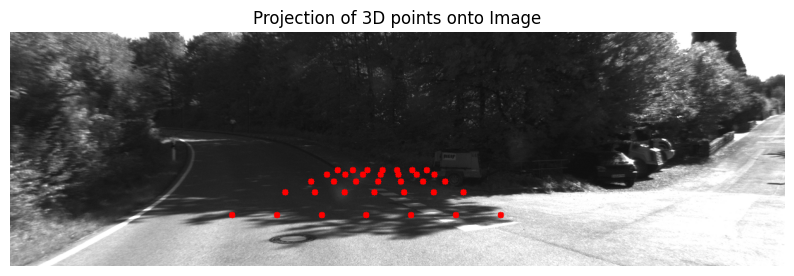

### Projection 결과 해석

임의의 3차원 점들을 생성한 후 Projection Matrix를 이용하여 이미지 좌표로 투영하였다. 
그 결과, 동일한 간격으로 배치된 3D 점들이 이미지 상에서는 일정하지 않게 분포하는 것을 확인할 수 있었다.

먼저, 카메라로부터 가까운 점들은 이미지 하단에 크게 분포하고, 
멀리 있는 점들은 점점 위쪽으로 모이며 작게 표현된다. 
이는 투영 과정에서 \( X_c / Z_c \), \( Y_c / Z_c \) 형태로 계산되기 때문이며, 
거리 \( Z_c \)가 증가할수록 좌표값이 작아져 물체가 작게 보이는 원근 효과를 반영한다.

또한, 동일한 간격으로 배치된 3D 점들이 이미지에서는 점점 좁아지는 형태로 나타나는데, 
이는 실제 평행한 선들이 이미지 상에서 한 점으로 수렴하는 소실점(vanishing point) 현상과 일치한다.

이러한 결과는 카메라 투영의 주요 특성인 원근 효과와 소실점 형성이 잘 반영된 것으로 볼 수 있다. 
따라서 Projection Matrix를 이용한 변환이 실제 카메라의 이미지 형성 원리와 일치함을 확인할 수 있다.

생성한 3차원 점들을 KITTI 카메라의 projection matrix를 이용하여 이미지 평면 위의 2차원 좌표로 투영하였다. 시각화 결과, 빨간 점들이 도로 위 특정 영역에 모여 나타나는 것을 확인할 수 있다. 이는 3D 공간상의 점들이 카메라 좌표계로 변환된 뒤, 초점거리와 주점 좌표를 기준으로 이미지 평면에 투영되기 때문이다.

카메라 투영에서는 깊이값 Z가 중요한 역할을 한다. 같은 실제 크기의 좌표 변화라도 카메라와 가까운 점은 이미지에서 더 크게 이동하고, 멀리 있는 점은 더 작게 이동한다. 그림에서도 아래쪽에 위치한 가까운 점들은 이미지상에서 더 넓게 퍼져 보이고, 위쪽에 위치한 먼 점들은 상대적으로 촘촘하게 모여 보인다. 이는 원근 투영의 특징과 일치한다.

또한 점들이 도로의 진행 방향을 따라 위쪽으로 갈수록 서로 가까워지는 형태를 보이는데, 이는 실제 3D 공간에서 멀어지는 점들이 이미지에서는 소실점 방향으로 수렴하는 카메라 투영 특성을 반영한다. 따라서 본 결과는 projection matrix가 3D 점의 위치와 깊이 정보를 이용하여 실제 카메라 영상 위의 2D 좌표로 변환한다는 것을 잘 보여준다.

임의의 3차원 점들을 생성한 후, Projection Matrix를 이용하여 이미지 평면 상의 2차원 좌표로 투영하였다. 그 결과, 3차원 공간에서 일정한 간격으로 배치된 점들이 이미지 상에서는 균일하지 않게 분포하는 것을 확인할 수 있었다.

먼저, 카메라에 가까운 점들은 이미지 하단에 넓게 분포하고, 거리가 먼 점들은 위쪽으로 갈수록 점점 밀집되어 나타난다. 이는 투영 과정에서 X_c / Z_c, Y_c / Z_c와 같은 형태로 좌표가 계산되기 때문이며, 깊이값 Z_c가 증가할수록 좌표값이 감소하여 물체가 작게 보이는 원근 효과를 반영한다.

또한, 동일한 간격으로 배치된 3차원 점들이 이미지 상에서는 점차 간격이 좁아지는 형태로 나타나는데, 이는 카메라 투영에서 평행한 구조가 이미지 상의 특정 지점으로 수렴하는 소실점(vanishing point) 현상과 일치한다. 특히 도로 방향으로 배치된 점들이 위쪽으로 갈수록 서로 가까워지는 모습은, 원거리로 갈수록 평행선이 한 점으로 모이는 원근 투영의 특성을 잘 보여준다.

따라서 본 결과는 Projection Matrix가 3차원 공간의 위치 및 깊이 정보를 기반으로 실제 카메라 영상과 유사한 2차원 이미지를 형성함을 보여주며, 원근 효과와 소실점 형성과 같은 카메라 투영의 주요 특성이 잘 반영되었음을 확인할 수 있다.

# 3. Pose 데이터를 이용한 차량 이동 궤적 시각화

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def plot_trajectory_2d_relative(pose_file):
    poses = []

    # 1. KITTI pose 파일 읽기
    with open(pose_file, "r") as f:
        for line in f:
            values = list(map(float, line.split()))
            T = np.array(values).reshape(3, 4)
            poses.append(T)

    # 2. 각 프레임의 카메라 위치 추출
    xs = []
    zs = []

    for T in poses:
        x = T[0, 3]
        z = T[2, 3]

        xs.append(x)
        zs.append(z)

    # 3. 초기 프레임을 기준 좌표계로 설정
    x0 = xs[0]
    z0 = zs[0]

    xs_relative = [x - x0 for x in xs]
    zs_relative = [z - z0 for z in zs]

    # 4. 프레임 간 이동 거리 계산
    distances = []

    for i in range(1, len(xs_relative)):
        dx = xs_relative[i] - xs_relative[i - 1]
        dz = zs_relative[i] - zs_relative[i - 1]
        distance = np.sqrt(dx**2 + dz**2)
        distances.append(distance)

    avg_distance = np.mean(distances)

    # 5. 2D 궤적 시각화
    plt.figure(figsize=(8, 6))

    plt.plot(xs_relative, zs_relative, label="Vehicle Trajectory")
    plt.scatter(xs_relative[0], zs_relative[0], color="red", label="Start")
    plt.scatter(xs_relative[-1], zs_relative[-1], color="blue", label="End")

    plt.xlabel("X position relative to first frame")
    plt.ylabel("Z position relative to first frame")
    plt.title("Vehicle Trajectory using KITTI Pose Data")
    plt.legend()
    plt.grid(True)
    plt.axis("equal")

    plt.show()

    # 6. 이동 정보 출력
    print("총 프레임 수:", len(poses))
    print("초기 위치:", (x0, z0))
    print("마지막 상대 위치:", (xs_relative[-1], zs_relative[-1]))
    print("프레임 간 평균 이동 거리:", avg_distance)


# 실행 예시
pose_file = "/Volumes/autonomous_mobility/dataset/poses/09.txt"
plot_trajectory_2d_relative(pose_file)

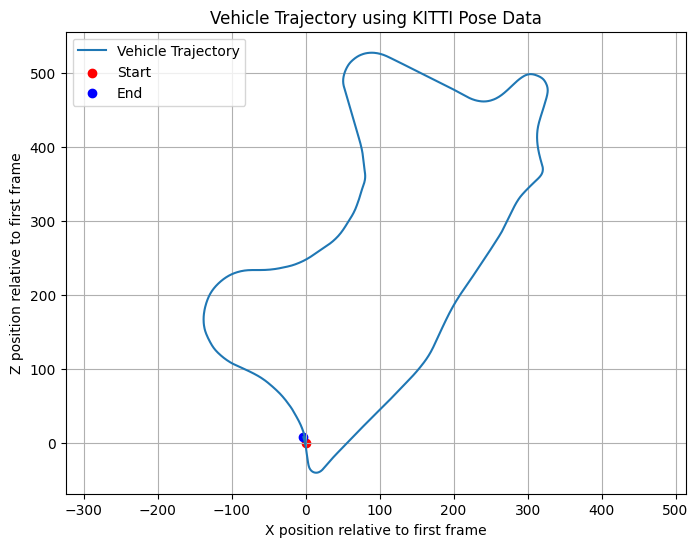

시각화된 차량 궤적을 통해 차량은 초기 위치를 기준으로 전반적으로 전방(X 증가 방향)으로 이동하면서, 경로 상에서 여러 차례 좌우 방향으로 회전하는 모습을 보인다. 궤적은 직선이 아닌 곡선 형태를 나타내며, 이는 차량이 단순 직진이 아닌 도로의 형태를 따라 주행했음을 의미한다. 특히 일부 구간에서는 급격한 방향 변화가 나타나는데, 이는 커브 구간에서의 조향 동작을 반영한 것으로 해석할 수 있다.

속도의 경우, 프레임 간 이동 거리의 변화를 통해 간접적으로 추정할 수 있다. 궤적에서 점 간 간격이 넓은 구간은 상대적으로 이동 속도가 빠른 구간을 의미하고, 반대로 간격이 좁은 구간은 속도가 감소한 구간으로 해석된다. 전체적으로는 큰 급가속이나 급감속 없이 비교적 일정한 속도로 주행하면서, 곡선 구간에서는 속도를 다소 줄이고 직선 구간에서는 다시 증가하는 경향을 보인다.

따라서 해당 궤적은 실제 차량 주행과 유사하게 도로의 곡률에 따라 방향을 변화시키며, 속도 또한 주행 환경에 맞게 자연스럽게 조절되는 특성을 보여준다.

# 4. 도로 영역 기반 차선 검출 및 기하학적 해석

bayesian 분류를 통해 도로 영역을 추출한 후, 해당 영역에서 edge 검출과 Hough Transform을 적용하여 차선 후보를 추출하였다. 
검출된 차선은 이미지 좌표계 상에서는 직선의 형태로 나타난다.

In [ ]:
"""
Minimal Bayesian road-vs-background classifier for KITTI grayscale frames.

Assumptions
-----------
- Images are KITTI odometry grayscale frames (image_0) sized 1241x376.
- Road pixels appear mostly in a bottom trapezoid; background near top band.
- Uses 1D intensity histograms with Laplace smoothing to estimate likelihoods.

Usage
-----
    --data-root dataset/sequences/00/image_0 \
    --train-frames 80 \
    --save-frames 10 \
    --out-dir outputs/bayes_road

Outputs
-------
- /mask_XXXXXX.png     : binary MAP mask (road=255, bg=0)
- /overlay_XXXXXX.png  : red overlay of road mask on original frame
- /prob_XXXXXX.png     : grayscale probability map (0-255)
"""
import argparse
import math
from pathlib import Path
import numpy as np
from PIL import Image
import cv2

def list_frames(data_root: Path) -> list[Path]:
    return sorted(data_root.glob("*.png"))

def get_trapezoid_mask(width: int, height: int, vp_y_rate=0.5, bottom_width_rate=0.9, top_width_rate=0.15):
    """
    소실점을 기준으로 도로 가능성이 높은 사다리꼴 마스크를 생성합니다.
    """
    mask = np.zeros((height, width), dtype=np.uint8)
    
    vp_y = int(height * vp_y_rate)  # 소실점 높이 (일반적으로 지평선 부근)
    
    # 사다리꼴 네 꼭짓점 정의
    p1 = [int(width * (0.5 - top_width_rate)), vp_y]
    p2 = [int(width * (0.5 + top_width_rate)), vp_y]
    p3 = [int(width * (0.5 + bottom_width_rate/2)), height]
    p4 = [int(width * (0.5 - bottom_width_rate/2)), height]
    
    pts = np.array([p1, p2, p3, p4], np.int32)
    cv2.fillPoly(mask, [pts], 1)
    return mask

def accumulate_weighted_histogram(img: np.ndarray, mask: np.ndarray) -> np.ndarray:
    """마스크 영역 내의 픽셀만 사용하여 히스토그램 생성"""
    pixels = img[mask > 0]
    counts = np.bincount(pixels.flatten(), minlength=256)
    return counts.astype(np.float64)

def classify_frame(img: np.ndarray, road_p: np.ndarray, bg_p: np.ndarray, prior_road: float) -> tuple[np.ndarray, np.ndarray]:
    """Return MAP mask and probability map for road class."""
    eps = 1e-10  # numerical stability
    log_p_road = np.log(road_p[img] + eps) + math.log(prior_road)
    log_p_bg = np.log(bg_p[img] + eps) + math.log(1 - prior_road)

    logit = log_p_road - log_p_bg
    prob = 1.0 / (1.0 + np.exp(-np.clip(logit, -15, 15)))
    mask = logit > 0
    return mask, prob

def run(
    data_root: Path,
    train_frames: int,
    save_frames: int,
    out_dir: Path,
    prior_road: float,
    alpha: float = 0.8,
    video_path: Path | None = None,
    video_fps: float = 10.0,
    vp_y_rate: float = 0.5,
    bottom_width_rate: float = 0.9,
    top_width_rate: float = 0.15,
    max_frames: int | None = None,
    gif_path: Path | None = None,
    gif_fps: float = 8.0,
):
    """
    alpha: 시계열 일관성 계수 (0.8이면 기존 지식 80%, 새 프레임 20% 반영)
    save_frames: -1 이면 모든 프레임 저장
    video_path: 지정 시 overlay 프레임을 영상으로 기록
    """
    frames = list_frames(data_root)
    if not frames:
        raise SystemExit(f"No PNG frames found in {data_root}")

    sample_img = np.array(Image.open(frames[0]), dtype=np.uint8)
    h, w = sample_img.shape
    
    # 1. 소실점 기반 마스크 생성
    road_mask = get_trapezoid_mask(w, h, vp_y_rate, bottom_width_rate, top_width_rate)
    bg_mask = 1 - road_mask  # 도로 외 영역은 배경으로 간주
    
    # 초기 확률 분포 설정 (Laplace smoothing)
    road_p_total = np.ones(256)
    bg_p_total = np.ones(256)

    out_dir.mkdir(parents=True, exist_ok=True)

    limit = len(frames) if max_frames is None else min(max_frames, len(frames))
    max_frames_eval = max(train_frames, limit if save_frames >= 0 else len(frames))
    frames_iter = frames[:max_frames_eval]

    writer = None
    if video_path is not None:
        suffix = video_path.suffix.lower()
        if suffix == ".mp4":
            fourcc = cv2.VideoWriter_fourcc(*"mp4v")
        else:  # default to MJPG/AVI
            fourcc = cv2.VideoWriter_fourcc(*"MJPG")
        writer = cv2.VideoWriter(str(video_path), fourcc, video_fps, (w, h))

    gif_frames: list[Image.Image] = []

    for idx, path in enumerate(frames_iter):
        img = np.array(Image.open(path), dtype=np.uint8)
        
        # 2. 현재 프레임의 히스토그램 추출
        curr_road_counts = accumulate_weighted_histogram(img, road_mask)
        curr_bg_counts = accumulate_weighted_histogram(img, bg_mask)
        
        # 3. 시계열 일관성 적용 (이동 평균)
        if idx == 0:
            road_p_total = curr_road_counts + 1
            bg_p_total = curr_bg_counts + 1
        else:
            # alpha 가중치를 이용해 이전 분포와 현재 분포를 결합
            road_p_total = alpha * road_p_total + (1 - alpha) * (curr_road_counts + 1)
            bg_p_total = alpha * bg_p_total + (1 - alpha) * (curr_bg_counts + 1)
        
        # 정규화하여 확률 밀도 함수 생성
        road_p = road_p_total / road_p_total.sum()
        bg_p = bg_p_total / bg_p_total.sum()

        # 4. 분류 및 저장 (save_frames 이내 혹은 영상 필요 시)
        should_save = (save_frames < 0 or idx < save_frames or writer is not None) and (max_frames is None or idx < max_frames)
        if should_save:
            mask, prob = classify_frame(img, road_p, bg_p, prior_road)

            stem = path.stem
            Image.fromarray((mask.astype(np.uint8) * 255)).save(out_dir / f"mask_{stem}.png")
            prob_img = np.clip(prob * 255, 0, 255).astype(np.uint8)
            Image.fromarray(prob_img).save(out_dir / f"prob_{stem}.png")

            overlay = np.stack([img, img, img], axis=-1)
            overlay[mask, 0] = 255  # 도로 영역 빨간색 강조
            overlay[mask, 1:] = (overlay[mask, 1:] * 0.3).astype(np.uint8)
            Image.fromarray(overlay).save(out_dir / f"overlay_{stem}.png")

            if writer is not None:
                writer.write(cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))

            if gif_path is not None:
                gif_frames.append(Image.fromarray(overlay))

            print(f"Processed {stem} with temporal consistency")

    if writer is not None:
        writer.release()

    if gif_path is not None and gif_frames:
        duration_ms = int(1000 / gif_fps)
        gif_frames[0].save(
            gif_path,
            save_all=True,
            append_images=gif_frames[1:],
            duration=duration_ms,
            loop=0,
        )

if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    
    parser.add_argument("--data-root", type=Path, default=Path("/Volumes/autonomous_mobility/dataset/sequences/09/image_0"))
    parser.add_argument("--train-frames", type=int, default=80)
    parser.add_argument("--save-frames", type=int, default=-1)
    parser.add_argument("--out-dir", type=Path, default=Path("outputs/bayes_road_advanced"))
    parser.add_argument("--prior-road", type=float, default=0.5)
    parser.add_argument("--alpha", type=float, default=0.85, help="Temporal consistency weight")
    parser.add_argument("--video-path", type=Path, default=None, help="if set, write overlay video here")
    parser.add_argument("--video-fps", type=float, default=10.0)
    parser.add_argument("--vp-y-rate", type=float, default=0.5, help="vanishing point height ratio")
    parser.add_argument("--bottom-width-rate", type=float, default=0.9)
    parser.add_argument("--top-width-rate", type=float, default=0.15)
    parser.add_argument("--max-frames", type=int, default=None, help="process at most this many frames (after sorting)")
    parser.add_argument("--gif-path", type=Path, default=None, help="optional GIF output of overlays")
    parser.add_argument("--gif-fps", type=float, default=8.0)
    
    args, unkown = parser.parse_known_args()
    
    run(
        args.data_root,
        args.train_frames,
        args.save_frames,
        args.out_dir,
        args.prior_road,
        args.alpha,
        args.video_path,
        args.video_fps,
        args.vp_y_rate,
        args.bottom_width_rate,
        args.top_width_rate,
        args.max_frames,
        args.gif_path,
        args.gif_fps,
    )


In [ ]:
import cv2
import numpy as np
from pathlib import Path


def extract_lane(mask):
    edges = cv2.Canny(mask, 50, 150)

    lines = cv2.HoughLinesP(
        edges,
        rho=1,
        theta=np.pi/180,
        threshold=50,
        minLineLength=50,
        maxLineGap=10
    )

    return lines


def process_all(mask_dir, image_dir, output_dir):
    mask_dir = Path(mask_dir)
    image_dir = Path(image_dir)
    output_dir = Path(output_dir)

    output_dir.mkdir(parents=True, exist_ok=True)

    mask_files = sorted(mask_dir.glob("mask_*.png"))

    for mask_path in mask_files:
        # 파일 이름에서 번호 추출
        frame_id = mask_path.stem.split("_")[1]

        image_path = image_dir / f"{frame_id}.png"

        if not image_path.exists():
            print(f"Image not found: {image_path}")
            continue

        # 이미지 로드
        mask = cv2.imread(str(mask_path), 0)
        img = cv2.imread(str(image_path))

        # 차선 검출
        lines = extract_lane(mask)

        # 그리기
        if lines is not None:
            for line in lines:
                x1, y1, x2, y2 = line[0]
                cv2.line(img, (x1,y1), (x2,y2), (0,255,0), 2)

        # 저장
        out_path = output_dir / f"lane_{frame_id}.png"
        cv2.imwrite(str(out_path), img)

        print(f"Saved: {out_path}")


# 🔥 실행
process_all(
    mask_dir="outputs/bayes_road_advanced",
    image_dir="/Volumes/autonomous_mobility/dataset/sequences/09/image_0",
    output_dir="outputs/lane_results"
)

### 4.1 이미지 좌표에서 검출된 차선의 의미

이미지 상에서 검출된 차선은 2차원 좌표 \((u, v)\)로 표현되지만, 이는 실제 3차원 공간에서의 직선이 Projection Matrix에 의해 투영된 결과이다.  
즉, 이미지에서의 직선은 카메라 좌표계에서 특정 방향을 가지는 3D 직선의 투영이라고 볼 수 있다.

특히, 도로 위의 차선은 실제 공간에서는 서로 평행한 구조를 가지지만, 이미지에서는 서로 가까워지며 한 점으로 수렴하는 형태로 나타난다.

---

### 4.2 도로를 평면으로 가정할 때 차선의 기하적 특성

도로를 하나의 평면(ground plane)이라고 가정하면, 차선은 이 평면 위에 존재하는 직선이다.  
이러한 직선들은 3차원 공간에서 서로 평행한 관계를 가지며 일정한 간격으로 배치되어 있다.

그러나 카메라 투영 과정에서는 원근 효과에 의해 다음과 같은 특성이 나타난다.

- 가까운 차선은 크게 보이고 간격이 넓다
- 먼 차선은 작게 보이며 서로 가까워진다
- 평행한 직선들이 이미지 상에서는 한 점으로 수렴한다

이러한 현상은 실제 도로에서 차선이 멀어질수록 좁아 보이는 것과 동일한 원리이다.

---

### 4.3 Projection Matrix와 소실점 및 기울기의 관계

Projection Matrix는 3D 공간의 점을 이미지 평면으로 투영할 때 원근 효과를 반영한다.  
이 과정에서 평행한 직선들은 이미지 상에서 하나의 점으로 수렴하게 되며, 이를 소실점(vanishing point)이라고 한다.

차선의 경우, 실제 도로에서는 서로 평행하지만, 이미지에서는 동일한 방향으로 기울어진 직선으로 나타나며, 이 직선들은 상단의 특정 지점으로 수렴하게 된다.

이 소실점의 위치는 카메라의 방향(R)과 위치(t)에 의해 결정되며, Projection Matrix의 구성 요소에 의해 결정된다.  
즉, 카메라가 바라보는 방향이 달라지면 소실점의 위치도 함께 변하게 된다.

---

### 4.4 종합

따라서 이미지에서 검출된 차선은 단순한 2D 직선이 아니라,  
3차원 공간에서의 평행한 직선이 Projection Matrix에 의해 투영된 결과이며,  
원근 효과와 소실점 형성을 통해 실제 카메라 영상의 기하적 특성을 반영하고 있음을 확인할 수 있다.

# 5. 차선 검출 실패 구간 분석

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_trajectory_with_point(pose_file, target_idx):
    poses = []

    with open(pose_file, "r") as f:
        for line in f:
            vals = list(map(float, line.split()))
            T = np.array(vals).reshape(3,4)
            poses.append(T)

    xs = [T[0,3] for T in poses]
    zs = [T[2,3] for T in poses]

    # 초기 프레임 기준
    x0, z0 = xs[0], zs[0]
    xs = [x - x0 for x in xs]
    zs = [z - z0 for z in zs]

    plt.figure(figsize=(8,6))
    plt.plot(xs, zs, label="Trajectory")

    # 실패 지점 표시
    plt.scatter(xs[target_idx], zs[target_idx],
                color='red', s=80, label=f'Failure Frame {target_idx}')

    plt.legend()
    plt.xlabel("X")
    plt.ylabel("Z")
    plt.title("Trajectory with Failure Point")
    plt.axis("equal")
    plt.show()


# 실행
plot_trajectory_with_point(
    "/Volumes/autonomous_mobility/dataset/poses/09.txt",
    356
)

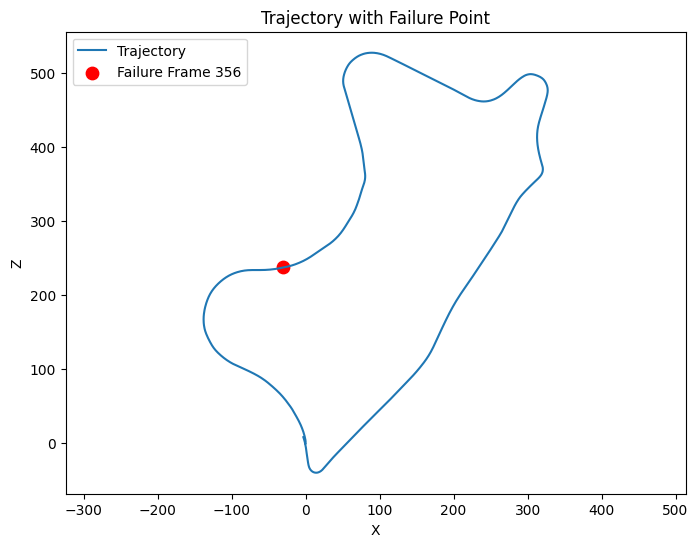

차량 궤적 중 frame 356 구간에서 차선 분류 성능이 저하되는 것을 확인하였다. 해당 프레임의 overlay 결과를 보면 도로 영역이 정확하게 분류되지 않고 일부 영역이 배경으로 잘못 분류되거나, 반대로 그림자 영역이 도로로 오분류되는 현상이 나타난다. 이 프레임을 궤적 상에 표시한 결과, 차량이 곡선 구간에 진입하는 위치에 해당함을 확인할 수 있다.

이와 같은 분류 실패는 여러 요인에 의해 발생한 것으로 분석된다. 먼저, 해당 구간에서는 나무와 구조물로 인해 강한 그림자가 도로 위에 형성되어 있으며, grayscale 기반 Bayesian 분류에서는 이러한 조명 변화가 도로와 배경을 구분하는 데 혼동을 유발한다. 또한 도로 표면의 질감 변화 역시 일정하지 않아 픽셀 intensity 기반 분류의 한계를 드러낸다.

차량의 주행 상태 역시 영향을 미친다. 해당 구간은 곡선 구간으로 차량이 회전하고 있으며, 이로 인해 카메라 시점이 변화하면서 기존에 설정된 도로 ROI(사다리꼴 영역)가 실제 도로 영역과 정확히 일치하지 않게 된다. 특히 소실점 기반으로 설정된 ROI는 직선 도로를 가정하고 있기 때문에, 곡선 구간에서는 도로 영역을 완전히 포함하지 못하는 한계가 존재한다.

따라서 본 실패 구간은 조명 변화, 도로 질감 변화, 차량의 회전, 그리고 ROI 가정의 한계가 복합적으로 작용하여 차선 분류 성능이 저하된 사례로 볼 수 있다.

차량 궤적 중 frame 13 구간에서 차선 및 도로 분류 성능이 크게 저하되는 것을 확인하였다. 해당 프레임의 overlay 결과를 보면 도로 영역뿐만 아니라 주변의 숲, 나무, 심지어 일부 배경 영역까지 도로로 잘못 분류되어 거의 전체 영역이 빨간색으로 표시되는 현상이 나타난다.

이와 같은 분류 실패는 조명 변화와 환경적 요인에 크게 영향을 받은 것으로 분석된다. 해당 구간은 햇빛이 강하게 비추는 환경으로, 도로뿐만 아니라 나무와 숲 영역에서도 밝은 intensity 값이 나타난다. 본 모델은 grayscale intensity 기반의 Bayesian 분류를 사용하기 때문에, 밝기 값이 유사한 영역을 동일한 클래스로 인식하는 한계를 가진다. 그 결과 실제 도로가 아닌 영역도 도로로 오분류되는 문제가 발생하였다.

또한 도로 표면의 질감이 일정하지 않고 주변 환경과의 대비가 약한 점도 원인으로 작용한다. 특히 나무와 잎사귀가 빽빽한 구간에서는 도로와 배경의 intensity 분포가 유사해져 히스토그램 기반 분류의 구분력이 떨어진다.

차량의 주행 상황 역시 영향을 미친다. 해당 프레임은 곡선 구간에 해당하며, 차량이 회전하면서 카메라의 시점이 변화한다. 이로 인해 사전에 설정된 사다리꼴 형태의 ROI가 실제 도로 영역과 정확히 일치하지 않게 되고, ROI 내에 포함된 배경 영역이 함께 학습되면서 분류 오류가 확대된다.

마지막으로 ROI 자체의 한계도 중요한 요인이다. 본 실험에서는 소실점을 기준으로 단순한 사다리꼴 형태의 ROI를 가정하였으나, 실제 도로는 곡선 형태를 가지며 주변 환경의 영향을 받기 때문에 이러한 단순 가정은 모든 상황에 적용되기 어렵다. 특히 숲과 같이 복잡한 배경이 포함된 경우 ROI 내부에 다양한 비도로 영역이 포함되면서 분류 성능이 크게 저하된다.

따라서 해당 실패 구간은 조명 변화, 도로 및 배경의 유사한 intensity 분포, 차량의 회전에 따른 시점 변화, 그리고 ROI 설정의 한계가 복합적으로 작용하여 발생한 사례로 볼 수 있다.

# 6. UFLD 모델을 활용한 딥러닝 기반 차선 검출

본 실험에서는 차선 검출을 위해 딥러닝 기반 모델인 **UFLD (Ultra Fast Lane Detection)**를 사용하였다. UFLD는 CNN 기반 구조를 활용하여 이미지에서 차선의 위치를 row anchor 기반으로 예측하는 모델로, 실시간 처리 속도와 높은 정확도를 동시에 달성하는 것이 특징이다. 특히 단순한 픽셀 기반 분류가 아닌, 학습된 특징(feature representation)을 활용하여 차선 구조를 인식할 수 있다는 장점이 있다.

In [ ]:
from pathlib import Path
import sys, os
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("/Users/heochaeyun/Desktop/vision_assignment")
LANE_ROOT = PROJECT_ROOT / "lane_detection"
UFLD_ROOT = LANE_ROOT / "Ultra-Fast-Lane-Detection"

sys.path.append(str(UFLD_ROOT))
os.chdir(PROJECT_ROOT)

from model.model import parsingNet
from data.constant import tusimple_row_anchor

In [ ]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

model = parsingNet(
    pretrained=False,
    backbone="18",
    cls_dim=(101, 56, 4),
    use_aux=False
).to(device)

model_path = UFLD_ROOT / "models" / "tusimple_18.pth"

checkpoint = torch.load(model_path, map_location=device)

state_dict = checkpoint["model"] if isinstance(checkpoint, dict) and "model" in checkpoint else checkpoint
state_dict = {k.replace("module.", ""): v for k, v in state_dict.items()}

model.load_state_dict(state_dict, strict=False)
model.eval()

print("모델 로드 완료")

In [ ]:
from pathlib import Path
import numpy as np
import cv2
import torch
import scipy.special
from data.constant import tusimple_row_anchor

image_dir = Path("/Volumes/autonomous_mobility/dataset/sequences/09/image_0")
output_dir = LANE_ROOT / "outputs" / "ufld_lane_results"
output_dir.mkdir(parents=True, exist_ok=True)

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

griding_num = 100
img_w, img_h = 800, 288
cls_num_per_lane = 56


def run_ufld_on_image(img_path):
    img = cv2.imread(str(img_path))
    if img is None:
        raise FileNotFoundError(img_path)

    img_resized = cv2.resize(img, (800, 288))

    img_input = img_resized.astype(np.float32) / 255.0
    img_input = (img_input - mean) / std
    img_input = img_input.transpose(2, 0, 1)
    img_input = torch.from_numpy(img_input).float().unsqueeze(0).to(device)

    with torch.no_grad():
        out = model(img_input)

    out_np = out[0].detach().cpu().numpy()

    out_j = out_np[:, ::-1, :]
    prob = scipy.special.softmax(out_j[:-1, :, :], axis=0)

    idx = np.arange(griding_num) + 1
    idx = idx.reshape(-1, 1, 1)

    loc = np.sum(prob * idx, axis=0)

    out_j_argmax = np.argmax(out_j, axis=0)
    loc[out_j_argmax == griding_num] = 0

    img_draw = img_resized.copy()

    for lane_idx in range(4):
        points = []

        for row_idx in range(cls_num_per_lane):
            if loc[row_idx, lane_idx] > 0:
                x = int(loc[row_idx, lane_idx] * img_w / griding_num)
                y = int(tusimple_row_anchor[cls_num_per_lane - 1 - row_idx])

                points.append((x, y))
                cv2.circle(img_draw, (x, y), 4, (0, 255, 0), -1)

        for i in range(len(points) - 1):
            cv2.line(img_draw, points[i], points[i + 1], (0, 255, 0), 2)

    return img_draw


frames = sorted(image_dir.glob("*.png"))

print("전체 프레임 수:", len(frames))

for i, img_path in enumerate(frames):
    result = run_ufld_on_image(img_path)

    save_path = output_dir / f"ufld_{img_path.stem}.png"
    cv2.imwrite(str(save_path), result)

    if i % 100 == 0:
        print(f"{i}/{len(frames)} 처리 완료: {img_path.name}")

print("전체 저장 완료:", output_dir)

그림 1. Bayesian 기반 차선 검출 결과  
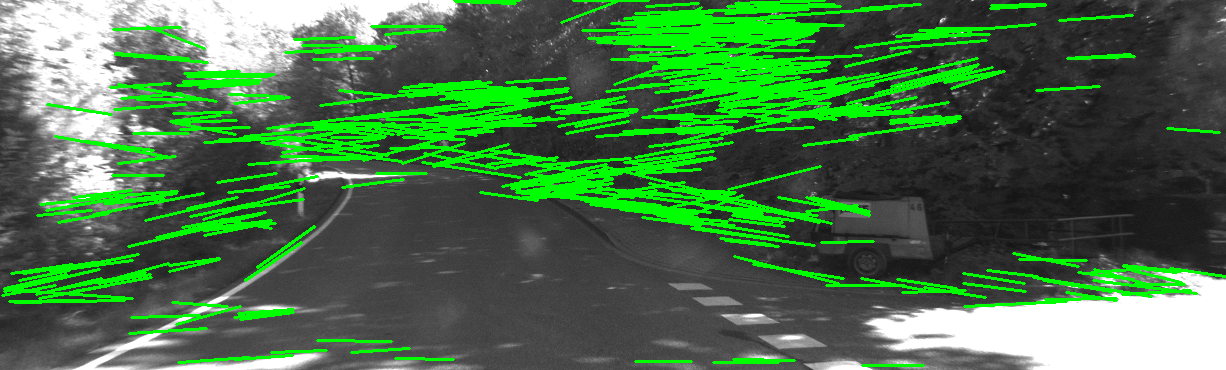

그림 2. UFLD 딥러닝 모델 기반 차선 검출 결과  
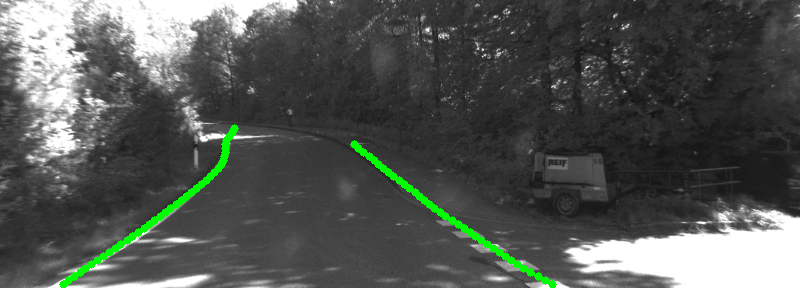

두 결과를 비교해보면, Bayesian 방식은 배경 환경에 크게 영향을 받아 오검출이 발생하는 반면, 
UFLD 모델은 차선의 구조적 정보를 기반으로 보다 정확하고 안정적인 검출 결과를 보인다.

UFLD 모델을 KITTI 데이터셋에 적용한 결과, Bayesian 기반 도로 분류 방식에 비해 훨씬 안정적인 차선 검출 결과를 확인할 수 있었다. Bayesian 방법은 픽셀의 밝기 분포에 의존하여 도로 영역을 구분하기 때문에, 조명 변화나 배경 질감에 큰 영향을 받는 반면, UFLD는 학습을 통해 차선의 형태적 특징을 인식하기 때문에 다양한 환경에서도 비교적 정확하게 차선을 검출하였다.

특히 숲길이나 그림자가 존재하는 구간에서는 Bayesian 방식이 도로가 아닌 영역까지 도로로 잘못 분류하는 문제가 발생하였다. 반면 UFLD는 차선의 연속성과 구조를 기반으로 판단하기 때문에, 동일한 구간에서도 실제 차선에 가까운 위치를 안정적으로 검출하였다. 이를 통해 딥러닝 기반 접근 방식이 전통적인 통계 기반 방법보다 복잡한 환경에서 더 높은 성능을 보인다는 것을 확인할 수 있었다.

결과적으로, 딥러닝 기반 모델은 단순한 픽셀 분포에 의존하는 방식보다 더 강건한(robust) 차선 검출 성능을 제공함을 확인하였다.